<a href="https://colab.research.google.com/github/hair-loss/Digital-Image-Processing-Homeworks/blob/main/%EC%98%81%EC%83%81%EC%B2%98%EB%A6%AC_HW7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [149]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

In [150]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [151]:
rena_blk = cv2.imread('/content/drive/MyDrive/ImageProcessingAssignment/rena-s.jpg', cv2.IMREAD_GRAYSCALE)

In [152]:
window1 = np.zeros([3, 3])
window1[1, 1] = 2
window2 = np.ones([3, 3])
print(window1)
window2= 1/9*window2
print(window2)

[[0. 0. 0.]
 [0. 2. 0.]
 [0. 0. 0.]]
[[0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]
 [0.11111111 0.11111111 0.11111111]]


In [153]:
print(window1.dtype)
print(window2.dtype)

float64
float64


In [154]:
rena_blk.shape
rena_pad = np.pad(rena_blk, pad_width=((1, 1), (1, 1)), mode = 'constant', constant_values=0)

In [155]:
def conv_2D_pad (image_mat, kernel):
  image = image_mat.astype(np.float64)
  kernel = kernel.astype(np.float64)
  result = np.zeros((image_mat.shape[0] - kernel.shape[0] + 1, image_mat.shape[1] - kernel.shape[1] + 1))
  for i in range(0, image_mat.shape[0] - kernel.shape[0] + 1):
    for j in range(0, image_mat.shape[1] - kernel.shape[1] + 1):
      block = image[i:i+kernel.shape[0], j:j+kernel.shape[1]]
      result[i, j] = np.sum(block*kernel)
  return result

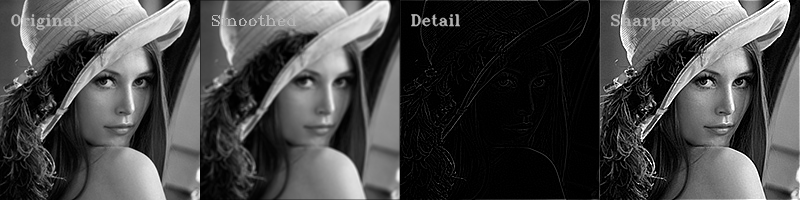

In [156]:
rena_up = conv_2D_pad(rena_pad, window1)
rena_smo = conv_2D_pad(rena_pad, window2)
rena_detail = np.clip(rena_blk.astype(np.int16) - rena_smo.astype(np.int16), 0, 255).astype(np.uint8)
rena_sharp = np.clip(rena_up.astype(np.int16) - rena_smo.astype(np.int16), 0, 255).astype(np.uint8)

cv2.putText(rena_blk, "Original", (10, 25), cv2.FONT_HERSHEY_TRIPLEX, 0.5, (180, 105, 255), 1, cv2.LINE_AA)
cv2.putText(rena_smo, "Smoothed", (10, 25), cv2.FONT_HERSHEY_TRIPLEX, 0.5, (180, 105, 255), 1, cv2.LINE_AA)
cv2.putText(rena_detail, "Detail", (10, 25), cv2.FONT_HERSHEY_TRIPLEX, 0.5, (180, 105, 255), 1, cv2.LINE_AA)
cv2.putText(rena_sharp, "Sharpened", (10, 25), cv2.FONT_HERSHEY_TRIPLEX, 0.5, (180, 105, 255), 1, cv2.LINE_AA)
combined = np.hstack([rena_blk, rena_smo, rena_detail, rena_sharp])
cv2_imshow(combined)